<a href="https://colab.research.google.com/github/NanC-Nabil/NTI/blob/main/Assignment1_NTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [3]:
model = Sequential([
    Input(shape=(28, 28)),      # Explicit Input layer for input shape
    Flatten(),                   # Flatten layer without input_shape
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# Fashion-MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

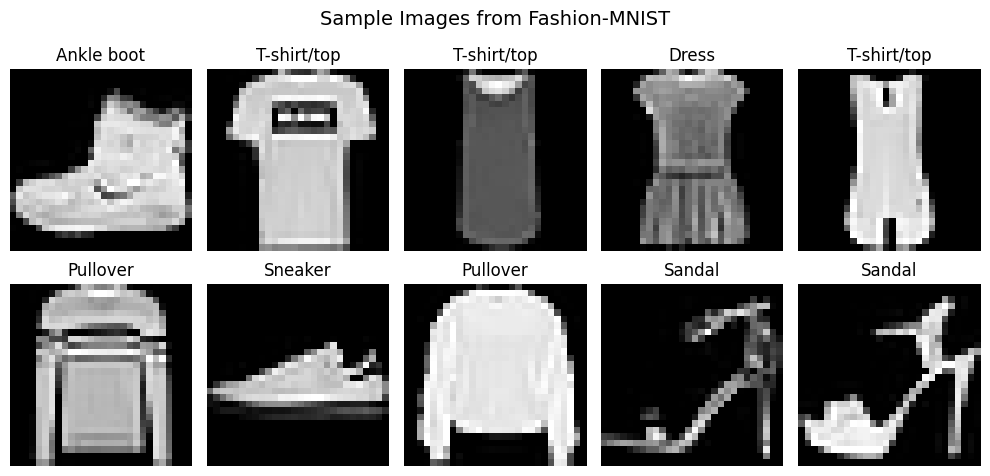

In [6]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample Images from Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8184 - loss: 0.5082 - val_accuracy: 0.8552 - val_loss: 0.3990
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8634 - loss: 0.3748 - val_accuracy: 0.8644 - val_loss: 0.3737
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8739 - loss: 0.3387 - val_accuracy: 0.8717 - val_loss: 0.3635
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8839 - loss: 0.3132 - val_accuracy: 0.8792 - val_loss: 0.3326
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8892 - loss: 0.2956 - val_accuracy: 0.8632 - val_loss: 0.3683
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8947 - loss: 0.2817 - val_accuracy: 0.8615 - val_loss: 0.3905
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8994 - loss: 0.2685 - val_accuracy: 0.8789 - val_loss: 0.3387
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9043 - loss: 0.2563 -

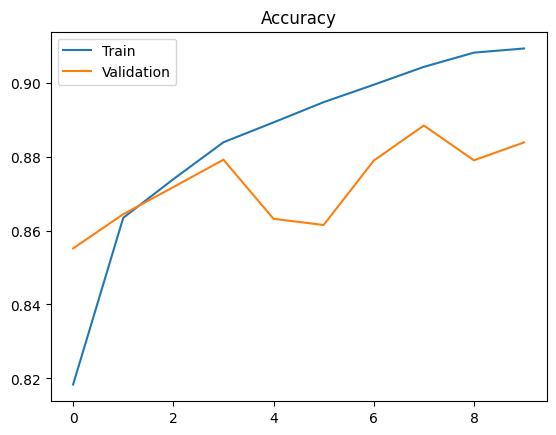

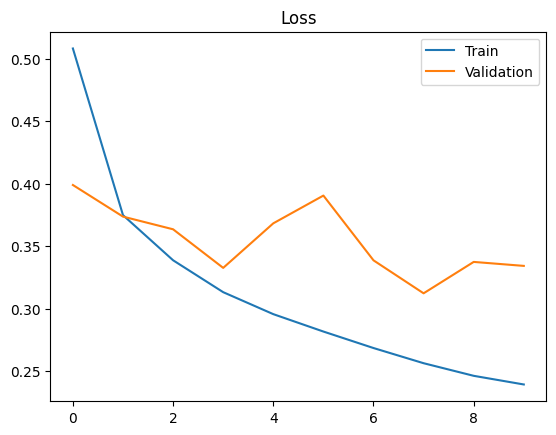

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Test Accuracy: 0.8743

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.79      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.79      0.79      1000
       Dress       0.84      0.91      0.87      1000
        Coat       0.79      0.81      0.80      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.71      0.68      0.69      1000
     Sneaker       0.87      0.98      0.92      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.98      0.87      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



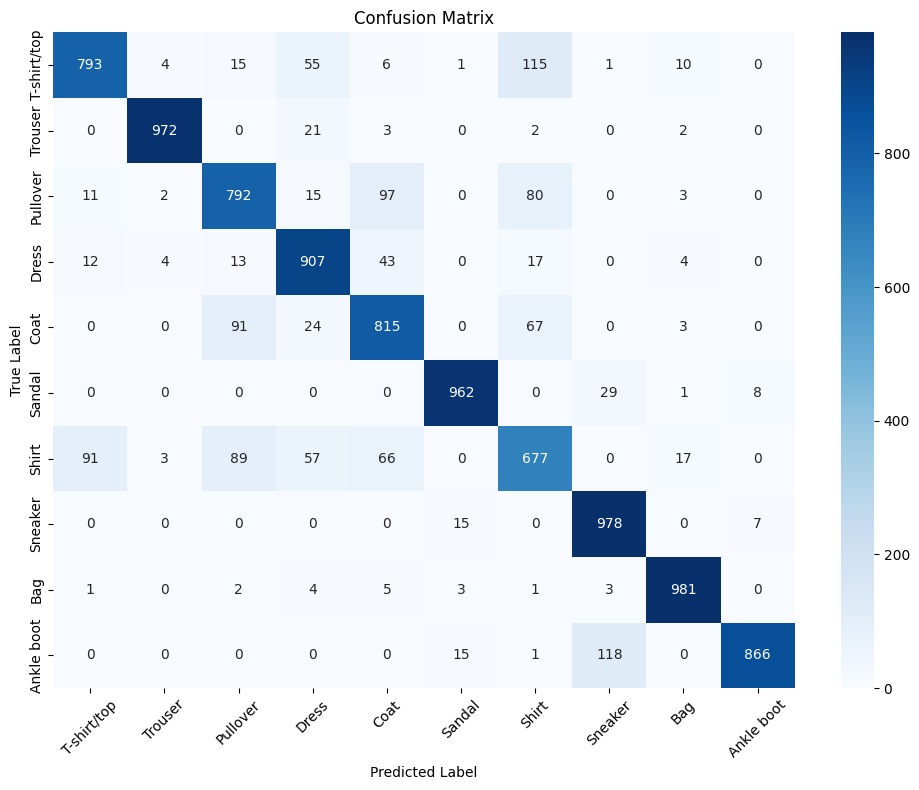

In [9]:
# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


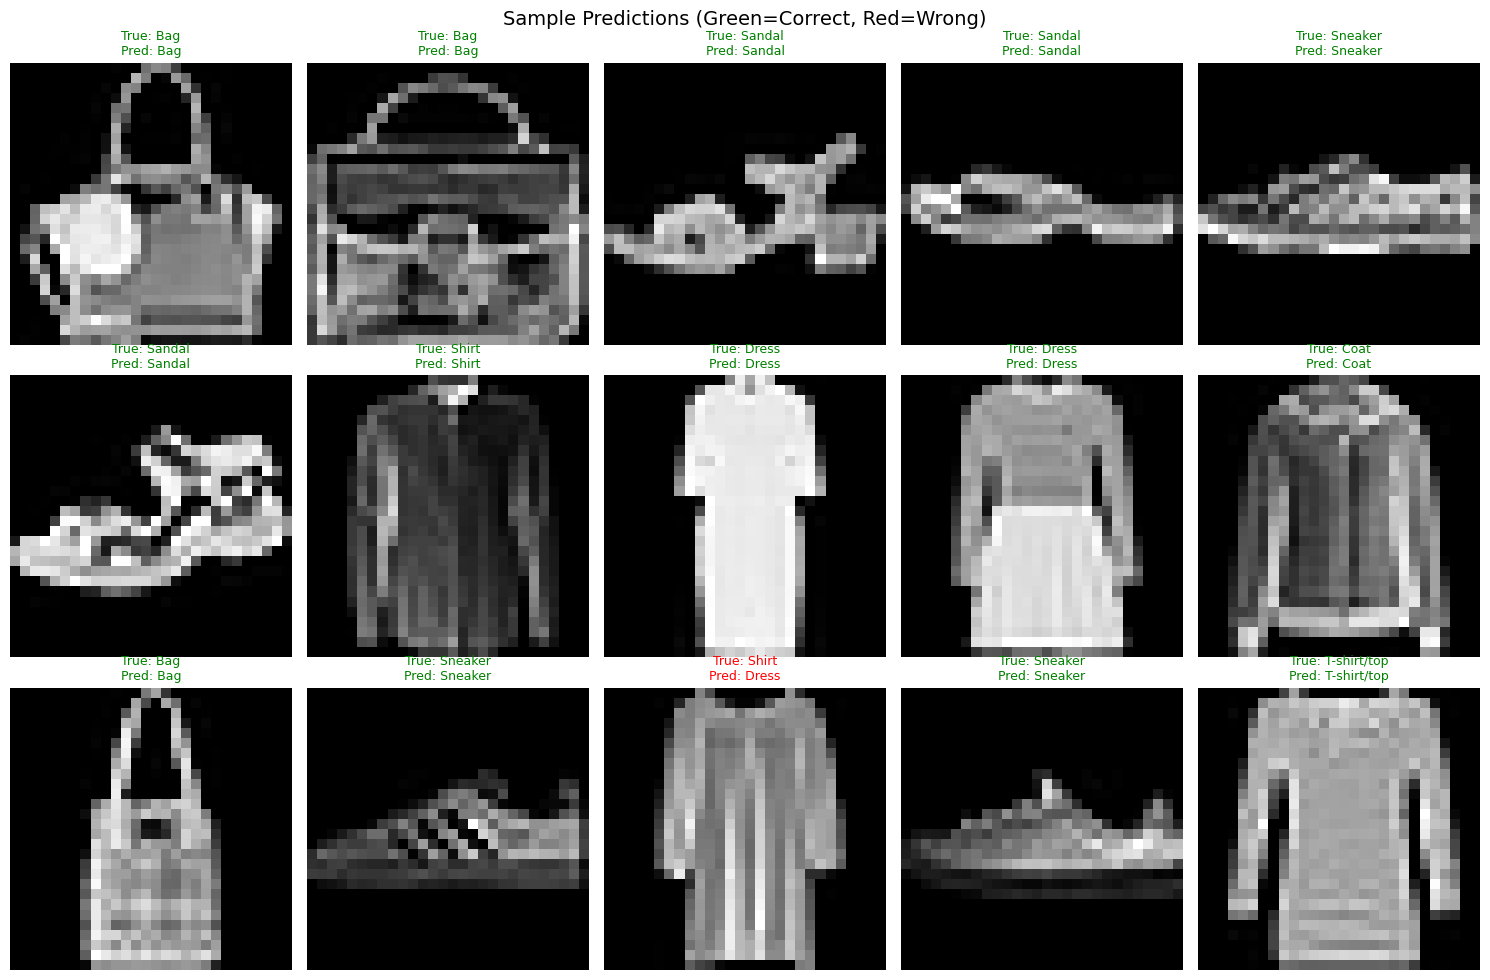

In [10]:
plt.figure(figsize=(15, 10))
indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    true_name = class_names[y_test[idx]]
    pred_name = class_names[y_pred[idx]]
    color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

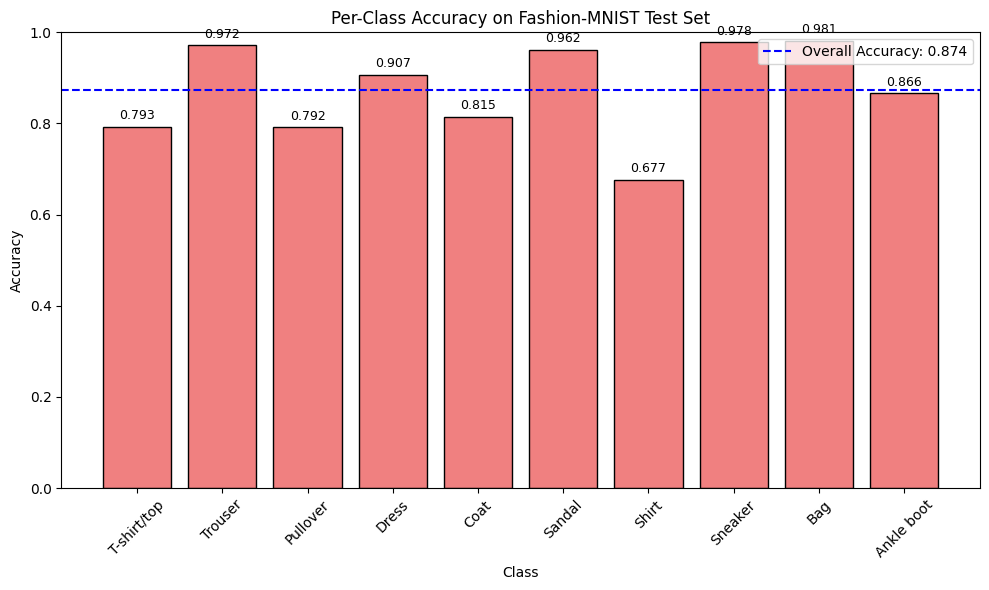

In [11]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, per_class_accuracy, color='lightcoral', edgecolor='black')
plt.axhline(y=test_accuracy, color='b', linestyle='--', label=f'Overall Accuracy: {test_accuracy:.3f}')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy on Fashion-MNIST Test Set')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()

# Add value labels on bars
for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()